# Task 2 — SQL for Data Extraction
**ApexPlanet Data Analytics Internship**  
**Dataset:** E-commerce Sales (Cleaned)  
**Timeline:** 7 Days (Day 7–13)

---

## 📋 What We Cover
| Days | Topic |
|------|-------|
| Day 7–8 | SQL Fundamentals |
| Day 9–10 | Advanced SQL (CTEs, Window Functions, Views) |
| Day 11–13 | Python + SQL Integration (10 Business Questions) |

---

## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine, text
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2: Load Cleaned Data into SQLite Database

In [2]:
# Load cleaned dataset from Task 1
df = pd.read_csv('../data/data_cleaned.csv')

# Create SQLite database connection
conn = sqlite3.connect('../data/ecommerce.db')

# Load dataframe into SQLite as table named 'orders'
df.to_sql('orders', conn, if_exists='replace', index=False)

print('✅ SQLite database created: data/ecommerce.db')
print(f'✅ Table "orders" loaded with {len(df):,} rows and {len(df.columns)} columns')
print(f'\nColumns: {list(df.columns)}')

✅ SQLite database created: data/ecommerce.db
✅ Table "orders" loaded with 333,234 rows and 12 columns

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Year', 'Month', 'Day', 'TotalPrice']


In [3]:
# Helper function — use this every time to run SQL queries
def run_query(query):
    """Run a SQL query and return result as a DataFrame"""
    return pd.read_sql_query(query, conn)

print('✅ Helper function ready! Use run_query("your SQL here") to run queries.')

✅ Helper function ready! Use run_query("your SQL here") to run queries.


---
# 📅 DAY 7–8: SQL FUNDAMENTALS

### 🟢 Query 1 — SELECT & LIMIT
View the first few rows of the table (like `df.head()`)

In [4]:
run_query("""
    SELECT *
    FROM orders
    LIMIT 5
""")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010,12,1,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010,12,1,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010,12,1,20.34


### 🟢 Query 2 — SELECT specific columns
Pick only the columns you need

In [5]:
run_query("""
    SELECT InvoiceNo, Description, Quantity, UnitPrice, TotalPrice, Country
    FROM orders
    LIMIT 10
""")

,InvoiceNo,Description,Quantity,UnitPrice,TotalPrice,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,United Kingdom
1,536365,WHITE METAL LANTERN,6,3.39,20.34,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,United Kingdom
5,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,25.50,United Kingdom
6,536366,HAND WARMER UNION JACK,6,1.85,11.10,United Kingdom
7,536366,HAND WARMER RED POLKA DOT,6,1.85,11.10,United Kingdom
8,536367,POPPY'S PLAYHOUSE BEDROOM,6,2.10,12.60,United Kingdom
9,536367,POPPY'S PLAYHOUSE KITCHEN,6,2.10,12.60,United Kingdom


### 🟢 Query 3 — WHERE (Filter rows)
Get only orders from the United Kingdom

In [6]:
run_query("""
    SELECT InvoiceNo, Description, Quantity, UnitPrice, Country
    FROM orders
    WHERE Country = 'United Kingdom'
    LIMIT 10
""")

,InvoiceNo,Description,Quantity,UnitPrice,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,United Kingdom
1,536365,WHITE METAL LANTERN,6,3.39,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,United Kingdom
5,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,United Kingdom
6,536366,HAND WARMER UNION JACK,6,1.85,United Kingdom
7,536366,HAND WARMER RED POLKA DOT,6,1.85,United Kingdom
8,536367,POPPY'S PLAYHOUSE BEDROOM,6,2.10,United Kingdom
9,536367,POPPY'S PLAYHOUSE KITCHEN,6,2.10,United Kingdom


### 🟢 Query 4 — WHERE with multiple conditions
Orders from UK with TotalPrice greater than 50

In [7]:
run_query("""
    SELECT InvoiceNo, Description, Quantity, TotalPrice, Country
    FROM orders
    WHERE Country = 'United Kingdom'
      AND TotalPrice > 50
    ORDER BY TotalPrice DESC
    LIMIT 10
""")

,InvoiceNo,Description,Quantity,TotalPrice,Country
0,565675,SMALL DECO JEWELLERY STAND,24,178.80,United Kingdom
1,569573,WALL ART KEEP CALM,24,178.80,United Kingdom
2,572769,WALL ART CLASSIC PUDDINGS,24,178.80,United Kingdom
3,573179,WALL ART CLASSIC PUDDINGS,24,178.80,United Kingdom
4,569651,DOORMAT AIRMAIL,24,169.92,United Kingdom
5,571289,DOORMAT RED RETROSPOT,24,169.92,United Kingdom
6,569362,KEEP CALM WALL ART,24,167.52,United Kingdom
7,539335,WOOD S/3 CABINET ANT WHITE FINISH,24,166.80,United Kingdom
8,541436,WOOD S/3 CABINET ANT WHITE FINISH,24,166.80,United Kingdom
9,546923,3 HOOK PHOTO SHELF ANTIQUE WHITE,24,166.80,United Kingdom


### 🟢 Query 5 — ORDER BY (Sort results)
Most expensive products first

In [8]:
run_query("""
    SELECT Description, UnitPrice
    FROM orders
    ORDER BY UnitPrice DESC
    LIMIT 10
""")

,Description,UnitPrice
0,PINK/WHITE GLASS DEMI CHOKER,7.5
1,FINE SILVER NECKLACE W PASTEL FLOWE,7.5
2,RESIN NECKLACE W PASTEL BEADS,7.5
3,FINE SILVER NECKLACE W PASTEL FLOWE,7.5
4,WHITE WIRE EGG HOLDER,7.5
5,SILVER BRACELET W PASTEL FLOWER,7.5
6,WHITE WIRE EGG HOLDER,7.5
7,WHITE WIRE EGG HOLDER,7.5
8,BULL DOG BOTTLE TOP WALL CLOCK,7.5
9,SILVER BRACELET W PASTEL FLOWER,7.5


### 🟢 Query 6 — GROUP BY + Aggregate Functions
Count total orders per country

In [9]:
run_query("""
    SELECT 
        Country,
        COUNT(*)            AS TotalOrders,
        SUM(TotalPrice)     AS TotalRevenue,
        AVG(TotalPrice)     AS AvgOrderValue,
        COUNT(DISTINCT CustomerID) AS UniqueCustomers
    FROM orders
    GROUP BY Country
    ORDER BY TotalRevenue DESC
    LIMIT 10
""")

,Country,TotalOrders,TotalRevenue,AvgOrderValue,UniqueCustomers
0,United Kingdom,300281,3680989.464,12.258483,3784
1,Germany,7448,137946.330,18.521258,92
2,France,6890,121978.940,17.703765,87
3,EIRE,5443,105899.620,19.456112,3
4,Spain,2040,29826.960,14.621059,29
5,Switzerland,1433,29790.460,20.788876,21
6,Belgium,1660,27839.110,16.770548,25
7,Portugal,1252,20408.770,16.300935,19
8,Norway,772,18123.260,23.475725,10
9,Netherlands,617,15578.900,25.249433,7


### 🟢 Query 7 — HAVING (Filter after GROUP BY)
Only show countries with revenue above £10,000

In [10]:
run_query("""
    SELECT 
        Country,
        ROUND(SUM(TotalPrice), 2) AS TotalRevenue
    FROM orders
    GROUP BY Country
    HAVING TotalRevenue > 10000
    ORDER BY TotalRevenue DESC
""")

,Country,TotalRevenue
0,United Kingdom,3680989.46
1,Germany,137946.33
2,France,121978.94
3,EIRE,105899.62
4,Spain,29826.96
5,Switzerland,29790.46
6,Belgium,27839.11
7,Portugal,20408.77
8,Norway,18123.26
9,Netherlands,15578.90


### 🟢 Query 8 — LIKE (Pattern Matching)
Find all products with 'CANDLE' in the name

In [11]:
run_query("""
    SELECT DISTINCT Description, UnitPrice
    FROM orders
    WHERE Description LIKE '%CANDLE%'
    ORDER BY UnitPrice DESC
    LIMIT 10
""")

,Description,UnitPrice
0,TALL ROCOCO CANDLE HOLDER,7.25
1,BLUE WIRE SPIRAL CANDLE HOLDER,6.35
2,PINK BAROQUE FLOCK CANDLE HOLDER,5.95
3,SILVER ROCOCO CANDLE STICK,5.95
4,CANDLEHOLDER PINK HANGING HEART,5.79
5,FORKED CACTUS CANDLE,5.79
6,WHITE HANGING BEADS CANDLE HOLDER,5.45
7,SET/3 POT PLANT CANDLES,5.45
8,GLASS SPHERE CANDLE STAND MEDIUM,5.45
9,SET/6 FROG PRINCE T-LIGHT CANDLES,4.96


---
# 📅 DAY 9–10: ADVANCED SQL

### 🔵 Query 9 — Subquery
Find customers who spent more than the average customer spend

In [12]:
run_query("""
    SELECT 
        CustomerID,
        ROUND(SUM(TotalPrice), 2) AS TotalSpend
    FROM orders
    GROUP BY CustomerID
    HAVING TotalSpend > (
        SELECT AVG(CustomerSpend)
        FROM (
            SELECT SUM(TotalPrice) AS CustomerSpend
            FROM orders
            GROUP BY CustomerID
        )
    )
    ORDER BY TotalSpend DESC
    LIMIT 10
""")

,CustomerID,TotalSpend
0,14911,84980.89
1,13089,36347.88
2,14096,36019.84
3,17841,32224.59
4,14298,24387.53
5,12748,20519.88
6,14156,18276.11
7,13081,17925.53
8,15311,17712.96
9,14088,15700.62


### 🔵 Query 10 — CTE (WITH clause)
Monthly revenue using a CTE — cleaner and more readable than subqueries

In [13]:
run_query("""
    WITH MonthlyRevenue AS (
        SELECT 
            Year,
            Month,
            ROUND(SUM(TotalPrice), 2) AS Revenue,
            COUNT(DISTINCT CustomerID) AS UniqueCustomers,
            COUNT(DISTINCT InvoiceNo)  AS TotalInvoices
        FROM orders
        GROUP BY Year, Month
    )
    SELECT *
    FROM MonthlyRevenue
    ORDER BY Year, Month
""")

,Year,Month,Revenue,UniqueCustomers,TotalInvoices
0,2010,12,284122.15,833,1270
1,2011,1,232767.98,701,904
2,2011,2,219192.88,703,895
3,2011,3,285458.42,919,1198
4,2011,4,242420.68,805,1034
5,2011,5,324899.44,1001,1389
6,2011,6,290158.85,939,1268
7,2011,7,289068.99,902,1213
8,2011,8,305233.84,878,1150
9,2011,9,480898.85,1195,1597


### 🔵 Query 11 — Window Function: ROW_NUMBER
Rank products by revenue within each country

In [14]:
try:
    display(run_query("""
        WITH ProductRevenue AS (
            SELECT 
                Country,
                Description,
                ROUND(SUM(TotalPrice), 2) AS Revenue
            FROM orders
            GROUP BY Country, Description
        )
        SELECT *,
            ROW_NUMBER() OVER (
                PARTITION BY Country 
                ORDER BY Revenue DESC
            ) AS RankInCountry
        FROM ProductRevenue
        WHERE Country IN ('United Kingdom', 'Germany', 'France')
        QUALIFY RankInCountry <= 3
    """))
except Exception as e:
    print(f"[ERROR] SQLite standard does not support QUALIFY directly:")
    print(f"  {e}")
    print("Note: QUALIFY is supported in analytical engines like BigQuery and Snowflake.")
    print("Please run the SQLite-compatible alternative below instead!")

[ERROR] SQLite standard does not support QUALIFY directly:
  Execution failed on sql '
        WITH ProductRevenue AS (
            SELECT 
                Country,
                Description,
                ROUND(SUM(TotalPrice), 2) AS Revenue
            FROM orders
            GROUP BY Country, Description
        )
        SELECT *,
            ROW_NUMBER() OVER (
                PARTITION BY Country 
                ORDER BY Revenue DESC
            ) AS RankInCountry
        FROM ProductRevenue
        WHERE Country IN ('United Kingdom', 'Germany', 'France')
        QUALIFY RankInCountry <= 3
    ': near "QUALIFY": syntax error
Note: QUALIFY is supported in analytical engines like BigQuery and Snowflake.
Please run the SQLite-compatible alternative below instead!


> ⚠️ Note: If you get an error on the QUALIFY clause (not supported in older SQLite), run the alternative below:

In [15]:
# Alternative without QUALIFY — works in all SQLite versions
run_query("""
    WITH ProductRevenue AS (
        SELECT 
            Country,
            Description,
            ROUND(SUM(TotalPrice), 2) AS Revenue
        FROM orders
        GROUP BY Country, Description
    ),
    Ranked AS (
        SELECT *,
            ROW_NUMBER() OVER (
                PARTITION BY Country 
                ORDER BY Revenue DESC
            ) AS RankInCountry
        FROM ProductRevenue
        WHERE Country IN ('United Kingdom', 'Germany', 'France')
    )
    SELECT * FROM Ranked
    WHERE RankInCountry <= 3
    ORDER BY Country, RankInCountry
""")

,Country,Description,Revenue,RankInCountry
0,France,ROUND SNACK BOXES SET OF4 WOODLAND,1593.00,1
1,France,RED TOADSTOOL LED NIGHT LIGHT,1555.95,2
2,France,PLASTERS IN TIN CIRCUS PARADE,1491.60,3
3,Germany,ROUND SNACK BOXES SET OF4 WOODLAND,3230.25,1
4,Germany,ROUND SNACK BOXES SET OF 4 FRUITS,1982.40,2
5,Germany,PLASTERS IN TIN WOODLAND ANIMALS,1353.00,3
6,United Kingdom,PARTY BUNTING,32456.40,1
7,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,29905.26,2
8,United Kingdom,JUMBO BAG RED RETROSPOT,21991.09,3


### 🔵 Query 12 — Window Function: RANK
Rank customers by total spending

In [16]:
run_query("""
    WITH CustomerSpend AS (
        SELECT 
            CustomerID,
            ROUND(SUM(TotalPrice), 2) AS TotalSpend,
            COUNT(DISTINCT InvoiceNo)  AS TotalOrders
        FROM orders
        GROUP BY CustomerID
    )
    SELECT *,
        RANK() OVER (ORDER BY TotalSpend DESC) AS SpendRank
    FROM CustomerSpend
    LIMIT 15
""")

,CustomerID,TotalSpend,TotalOrders,SpendRank
0,14911,84980.89,193,1
1,13089,36347.88,80,2
2,14096,36019.84,17,3
3,17841,32224.59,123,4
4,14298,24387.53,40,5
5,12748,20519.88,196,6
6,14156,18276.11,41,7
7,13081,17925.53,10,8
8,15311,17712.96,91,9
9,14088,15700.62,12,10


### 🔵 Query 13 — Window Function: LAG (Month-over-Month Growth)
Compare each month's revenue to the previous month

In [17]:
run_query("""
    WITH MonthlyRevenue AS (
        SELECT 
            Year,
            Month,
            ROUND(SUM(TotalPrice), 2) AS Revenue
        FROM orders
        GROUP BY Year, Month
    )
    SELECT 
        Year,
        Month,
        Revenue,
        LAG(Revenue) OVER (ORDER BY Year, Month) AS PrevMonthRevenue,
        ROUND(
            (Revenue - LAG(Revenue) OVER (ORDER BY Year, Month)) 
            / LAG(Revenue) OVER (ORDER BY Year, Month) * 100, 2
        ) AS GrowthPct
    FROM MonthlyRevenue
    ORDER BY Year, Month
""")

,Year,Month,Revenue,PrevMonthRevenue,GrowthPct
0,2010,12,284122.15,NaN,NaN
1,2011,1,232767.98,284122.15,-18.07
2,2011,2,219192.88,232767.98,-5.83
3,2011,3,285458.42,219192.88,30.23
4,2011,4,242420.68,285458.42,-15.08
5,2011,5,324899.44,242420.68,34.02
6,2011,6,290158.85,324899.44,-10.69
7,2011,7,289068.99,290158.85,-0.38
8,2011,8,305233.84,289068.99,5.59
9,2011,9,480898.85,305233.84,57.55


### 🔵 Query 14 — Create a VIEW
Views are saved queries you can reuse anytime like a virtual table

In [18]:
# Create a reusable view for customer summary
conn.execute("""
    DROP VIEW IF EXISTS customer_summary
""")

conn.execute("""
    CREATE VIEW customer_summary AS
    SELECT 
        CustomerID,
        Country,
        COUNT(DISTINCT InvoiceNo)  AS TotalOrders,
        ROUND(SUM(TotalPrice), 2)  AS TotalSpend,
        ROUND(AVG(TotalPrice), 2)  AS AvgOrderValue,
        MIN(InvoiceDate)           AS FirstPurchase,
        MAX(InvoiceDate)           AS LastPurchase
    FROM orders
    GROUP BY CustomerID, Country
""")

print('✅ View "customer_summary" created!')

# Query the view
run_query("""
    SELECT * FROM customer_summary
    ORDER BY TotalSpend DESC
    LIMIT 10
""")

✅ View "customer_summary" created!


,CustomerID,Country,TotalOrders,TotalSpend,AvgOrderValue,FirstPurchase,LastPurchase
0,14911,EIRE,193,84980.89,18.94,2010-12-01 14:05:00,2011-12-08 15:54:00
1,13089,United Kingdom,80,36347.88,24.10,2010-12-06 13:59:00,2011-12-05 14:30:00
2,14096,United Kingdom,17,36019.84,8.16,2011-08-30 10:49:00,2011-12-05 17:17:00
3,17841,United Kingdom,123,32224.59,4.47,2010-12-01 14:41:00,2011-12-08 12:07:00
4,14298,United Kingdom,40,24387.53,24.12,2010-12-14 12:59:00,2011-12-01 13:12:00
5,12748,United Kingdom,196,20519.88,5.07,2010-12-01 12:48:00,2011-12-09 12:20:00
6,14156,EIRE,41,18276.11,22.18,2011-01-14 14:11:00,2011-11-30 10:54:00
7,13081,United Kingdom,10,17925.53,21.21,2010-12-03 17:20:00,2011-11-28 10:54:00
8,15311,United Kingdom,91,17712.96,9.26,2010-12-01 09:41:00,2011-12-09 12:00:00
9,14088,United Kingdom,12,15700.62,53.59,2011-01-21 13:07:00,2011-11-29 16:16:00


---
# 📅 DAY 11–13: PYTHON + SQL INTEGRATION
## 10 Business Questions Answered with SQL

### Connect via SQLAlchemy (Professional way)

In [19]:
# Connect using SQLAlchemy engine
engine = create_engine('sqlite:///../data/ecommerce.db')

def query(sql):
    """Run SQL using SQLAlchemy engine"""
    with engine.connect() as connection:
        return pd.read_sql(text(sql), connection)

print('✅ SQLAlchemy engine connected!')

✅ SQLAlchemy engine connected!


---
### ❓ Business Question 1 — What are the Top 5 Products by Revenue?

💡 Q1: Top 5 Products by Revenue


,Description,TotalRevenue,TotalUnitsSold
0,PARTY BUNTING,34952.85,7085
1,WHITE HANGING HEART T-LIGHT HOLDER,31763.76,10784
2,JUMBO BAG RED RETROSPOT,24923.50,12167
3,SPOTTY BUNTING,23513.05,4755
4,ASSORTED COLOUR BIRD ORNAMENT,22940.06,13574


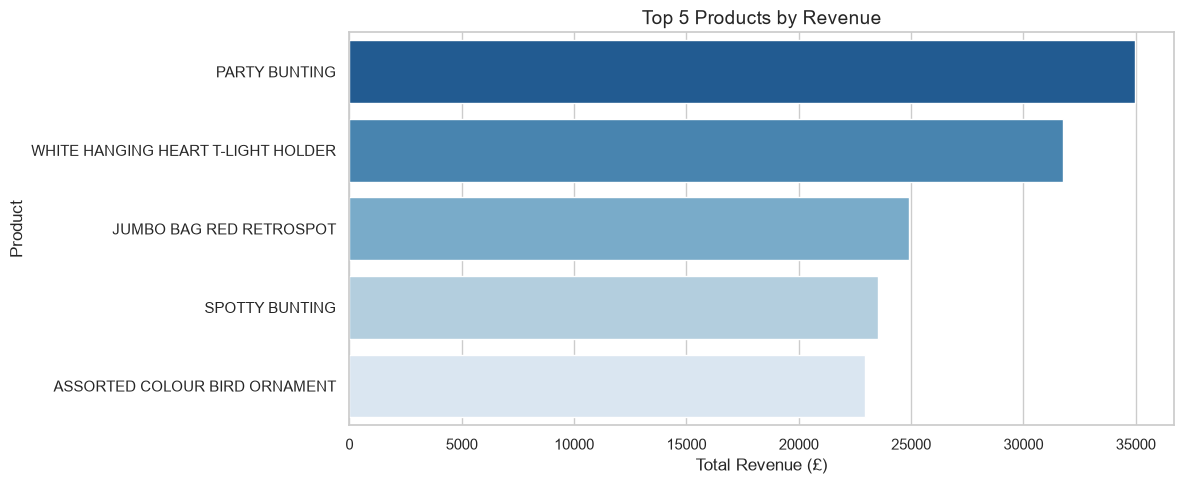

In [20]:
q1 = query("""
    SELECT 
        Description,
        ROUND(SUM(TotalPrice), 2) AS TotalRevenue,
        SUM(Quantity)             AS TotalUnitsSold
    FROM orders
    GROUP BY Description
    ORDER BY TotalRevenue DESC
    LIMIT 5
""")

print('💡 Q1: Top 5 Products by Revenue')
display(q1)

# Visualize
plt.figure(figsize=(12, 5))
sns.barplot(data=q1, x='TotalRevenue', y='Description', palette='Blues_r')
plt.title('Top 5 Products by Revenue', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('../reports/sql_q1_top_products.png', dpi=150)
plt.show()

### ❓ Business Question 2 — What is the Monthly Sales Trend?

💡 Q2: Monthly Sales Trend


,Year,Month,MonthlyRevenue,TotalOrders,UniqueCustomers,Period
0,2010,12,284122.15,1270,833,2010-12
1,2011,1,232767.98,904,701,2011-01
2,2011,2,219192.88,895,703,2011-02
3,2011,3,285458.42,1198,919,2011-03
4,2011,4,242420.68,1034,805,2011-04
5,2011,5,324899.44,1389,1001,2011-05
6,2011,6,290158.85,1268,939,2011-06
7,2011,7,289068.99,1213,902,2011-07
8,2011,8,305233.84,1150,878,2011-08
9,2011,9,480898.85,1597,1195,2011-09


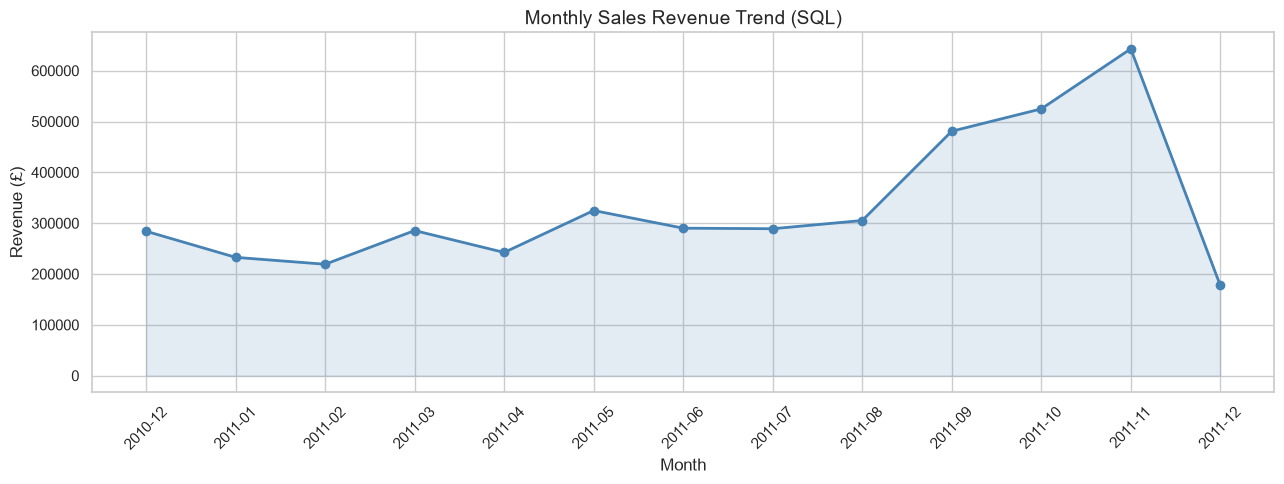

In [21]:
q2 = query("""
    SELECT 
        Year,
        Month,
        ROUND(SUM(TotalPrice), 2)      AS MonthlyRevenue,
        COUNT(DISTINCT InvoiceNo)       AS TotalOrders,
        COUNT(DISTINCT CustomerID)      AS UniqueCustomers
    FROM orders
    GROUP BY Year, Month
    ORDER BY Year, Month
""")

q2['Period'] = q2['Year'].astype(str) + '-' + q2['Month'].astype(str).str.zfill(2)

print('💡 Q2: Monthly Sales Trend')
display(q2)

plt.figure(figsize=(13, 5))
plt.plot(q2['Period'], q2['MonthlyRevenue'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(q2)), q2['MonthlyRevenue'], alpha=0.15, color='steelblue')
plt.title('Monthly Sales Revenue Trend (SQL)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(range(len(q2)), q2['Period'], rotation=45)
plt.tight_layout()
plt.savefig('../reports/sql_q2_monthly_trend.png', dpi=150)
plt.show()

### ❓ Business Question 3 — Who are the Top 10 Customers by Spend?

In [22]:
q3 = query("""
    SELECT 
        CustomerID,
        Country,
        ROUND(SUM(TotalPrice), 2)  AS TotalSpend,
        COUNT(DISTINCT InvoiceNo)  AS TotalOrders,
        ROUND(AVG(TotalPrice), 2)  AS AvgOrderValue
    FROM orders
    GROUP BY CustomerID
    ORDER BY TotalSpend DESC
    LIMIT 10
""")

print('💡 Q3: Top 10 Customers by Total Spend')
display(q3)

💡 Q3: Top 10 Customers by Total Spend


,CustomerID,Country,TotalSpend,TotalOrders,AvgOrderValue
0,14911,EIRE,84980.89,193,18.94
1,13089,United Kingdom,36347.88,80,24.10
2,14096,United Kingdom,36019.84,17,8.16
3,17841,United Kingdom,32224.59,123,4.47
4,14298,United Kingdom,24387.53,40,24.12
5,12748,United Kingdom,20519.88,196,5.07
6,14156,EIRE,18276.11,41,22.18
7,13081,United Kingdom,17925.53,10,21.21
8,15311,United Kingdom,17712.96,91,9.26
9,14088,United Kingdom,15700.62,12,53.59


### ❓ Business Question 4 — Customer Segmentation by Spend Level

💡 Q4: Customer Segmentation by Spend Level


,CustomerSegment,CustomerCount,SegmentRevenue,AvgSpendPerCustomer
0,Mid Value (£1000–£4999),1075,2212175.87,2057.84
1,High Value (≥£5000),107,1001824.79,9362.85
2,Low Value (£200–£999),2002,972276.21,485.65
3,Occasional (<£200),1007,113199.31,112.41


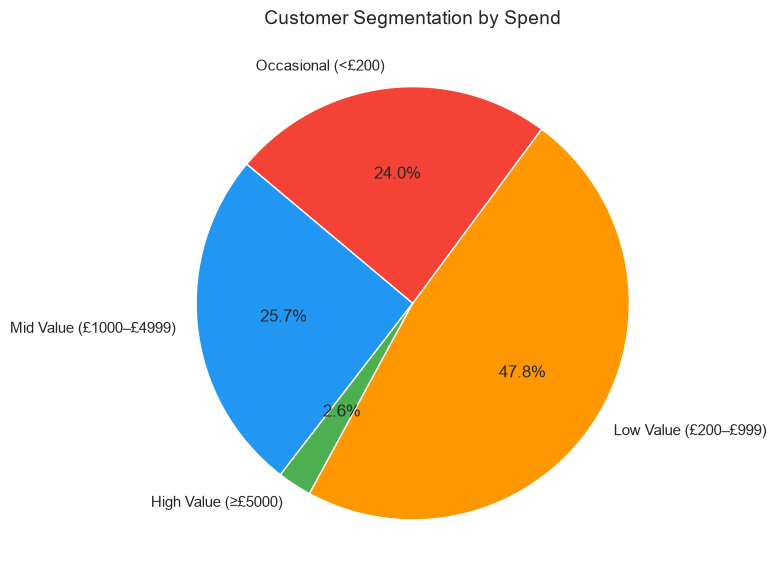

In [23]:
q4 = query("""
    WITH CustomerSpend AS (
        SELECT 
            CustomerID,
            SUM(TotalPrice) AS TotalSpend
        FROM orders
        GROUP BY CustomerID
    )
    SELECT 
        CASE 
            WHEN TotalSpend >= 5000 THEN 'High Value (≥£5000)'
            WHEN TotalSpend >= 1000 THEN 'Mid Value (£1000–£4999)'
            WHEN TotalSpend >= 200  THEN 'Low Value (£200–£999)'
            ELSE 'Occasional (<£200)'
        END AS CustomerSegment,
        COUNT(*)                       AS CustomerCount,
        ROUND(SUM(TotalSpend), 2)      AS SegmentRevenue,
        ROUND(AVG(TotalSpend), 2)      AS AvgSpendPerCustomer
    FROM CustomerSpend
    GROUP BY CustomerSegment
    ORDER BY SegmentRevenue DESC
""")

print('💡 Q4: Customer Segmentation by Spend Level')
display(q4)

# Pie chart
plt.figure(figsize=(8, 6))
plt.pie(q4['CustomerCount'], labels=q4['CustomerSegment'],
        autopct='%1.1f%%', startangle=140,
        colors=['#2196F3','#4CAF50','#FF9800','#F44336'])
plt.title('Customer Segmentation by Spend', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/sql_q4_customer_segments.png', dpi=150)
plt.show()

### ❓ Business Question 5 — Which Countries Generate the Most Revenue?

💡 Q5: Top 10 Countries by Revenue


,Country,TotalRevenue,UniqueCustomers,TotalOrders,AvgOrderValue
0,United Kingdom,3680989.46,3784,15144,12.26
1,Germany,137946.33,92,425,18.52
2,France,121978.94,87,362,17.70
3,EIRE,105899.62,3,238,19.46
4,Spain,29826.96,29,82,14.62
5,Switzerland,29790.46,21,43,20.79
6,Belgium,27839.11,25,93,16.77
7,Portugal,20408.77,19,46,16.30
8,Norway,18123.26,10,34,23.48
9,Netherlands,15578.90,7,65,25.25


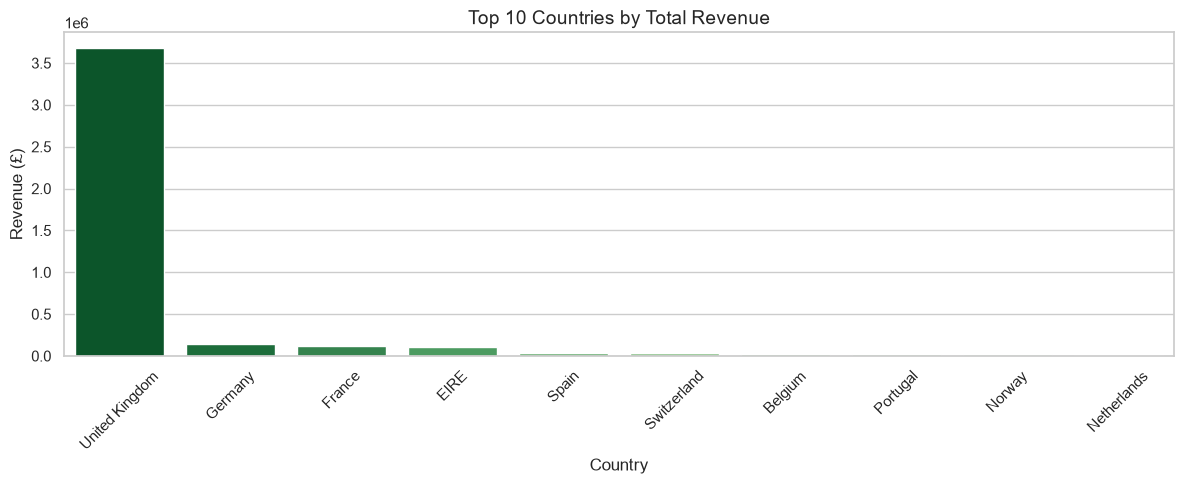

In [24]:
q5 = query("""
    SELECT 
        Country,
        ROUND(SUM(TotalPrice), 2)      AS TotalRevenue,
        COUNT(DISTINCT CustomerID)      AS UniqueCustomers,
        COUNT(DISTINCT InvoiceNo)       AS TotalOrders,
        ROUND(AVG(TotalPrice), 2)       AS AvgOrderValue
    FROM orders
    GROUP BY Country
    ORDER BY TotalRevenue DESC
    LIMIT 10
""")

print('💡 Q5: Top 10 Countries by Revenue')
display(q5)

plt.figure(figsize=(12, 5))
sns.barplot(data=q5, x='Country', y='TotalRevenue', palette='Greens_r')
plt.title('Top 10 Countries by Total Revenue', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/sql_q5_country_revenue.png', dpi=150)
plt.show()

### ❓ Business Question 6 — What is the Best Day of the Week for Sales?

In [25]:
q6 = query("""
    SELECT 
        CASE CAST(strftime('%w', InvoiceDate) AS INTEGER)
            WHEN 0 THEN 'Sunday'
            WHEN 1 THEN 'Monday'
            WHEN 2 THEN 'Tuesday'
            WHEN 3 THEN 'Wednesday'
            WHEN 4 THEN 'Thursday'
            WHEN 5 THEN 'Friday'
            WHEN 6 THEN 'Saturday'
        END AS DayOfWeek,
        COUNT(DISTINCT InvoiceNo)      AS TotalOrders,
        ROUND(SUM(TotalPrice), 2)      AS TotalRevenue,
        ROUND(AVG(TotalPrice), 2)      AS AvgOrderValue
    FROM orders
    GROUP BY DayOfWeek
    ORDER BY TotalRevenue DESC
""")

print('💡 Q6: Best Day of the Week for Sales')
display(q6)

💡 Q6: Best Day of the Week for Sales


,DayOfWeek,TotalOrders,TotalRevenue,AvgOrderValue
0,Thursday,3672,927269.41,14.03
1,Wednesday,3096,771937.56,13.58
2,Tuesday,2864,744324.30,13.44
3,Monday,2587,702198.86,12.86
4,Friday,2530,647459.81,14.12
5,Sunday,2077,506286.24,9.30


### ❓ Business Question 7 — What is the Average Order Value per Country?

In [26]:
q7 = query("""
    SELECT 
        Country,
        ROUND(AVG(OrderTotal), 2)   AS AvgOrderValue,
        COUNT(*)                    AS TotalOrders
    FROM (
        SELECT 
            Country,
            InvoiceNo,
            SUM(TotalPrice) AS OrderTotal
        FROM orders
        GROUP BY Country, InvoiceNo
    )
    GROUP BY Country
    HAVING TotalOrders >= 10
    ORDER BY AvgOrderValue DESC
    LIMIT 10
""")

print('💡 Q7: Average Order Value by Country (min 10 orders)')
display(q7)

💡 Q7: Average Order Value by Country (min 10 orders)


,Country,AvgOrderValue,TotalOrders
0,Switzerland,692.80,43
1,Cyprus,614.36,12
2,Norway,533.04,34
3,Channel Islands,523.18,21
4,Denmark,477.42,16
5,EIRE,444.96,238
6,Portugal,443.67,46
7,Austria,393.06,17
8,Spain,363.74,82
9,Italy,362.21,33


### ❓ Business Question 8 — Which Products Have Never Been Reordered? (Single Invoice)

In [27]:
q8 = query("""
    SELECT 
        Description,
        COUNT(DISTINCT InvoiceNo)  AS TimesOrdered,
        SUM(Quantity)              AS TotalQtySold,
        ROUND(SUM(TotalPrice), 2)  AS TotalRevenue
    FROM orders
    GROUP BY Description
    HAVING TimesOrdered = 1
    ORDER BY TotalRevenue DESC
    LIMIT 10
""")

print('💡 Q8: Products Ordered Only Once (No Repeat Orders)')
display(q8)

💡 Q8: Products Ordered Only Once (No Repeat Orders)

,Description,TimesOrdered,TotalQtySold,TotalRevenue
0,SMALL DECO JEWELLERY STAND,1,24,178.80
1,RECYCLED ACAPULCO MAT TURQUOISE,1,20,149.00
2,RECYCLED ACAPULCO MAT RED,1,20,149.00
3,TRIPLE PHOTO FRAME CORNICE,1,16,107.52
4,FAMILY PHOTO FRAME CORNICE,1,16,107.52
5,OVAL WALL MIRROR DIAMANTE,1,24,94.80
6,FAMILY ALBUM WHITE PICTURE FRAME,1,16,90.24
7,MARIE ANTOINETTE TRINKET BOX SILVER,1,24,72.00
8,MARIE ANTOINETTE TRINKET BOX GOLD,1,24,72.00
9,IVORY RETRO KITCHEN WALL CLOCK,1,10,70.50


### ❓ Business Question 9 — Month-over-Month Revenue Growth Rate

💡 Q9: Month-over-Month Revenue Growth %


,Year,Month,Revenue,PrevRevenue,GrowthPct
0,2010,12,284122.15,NaN,NaN
1,2011,1,232767.98,284122.15,-18.07
2,2011,2,219192.88,232767.98,-5.83
3,2011,3,285458.42,219192.88,30.23
4,2011,4,242420.68,285458.42,-15.08
5,2011,5,324899.44,242420.68,34.02
6,2011,6,290158.85,324899.44,-10.69
7,2011,7,289068.99,290158.85,-0.38
8,2011,8,305233.84,289068.99,5.59
9,2011,9,480898.85,305233.84,57.55


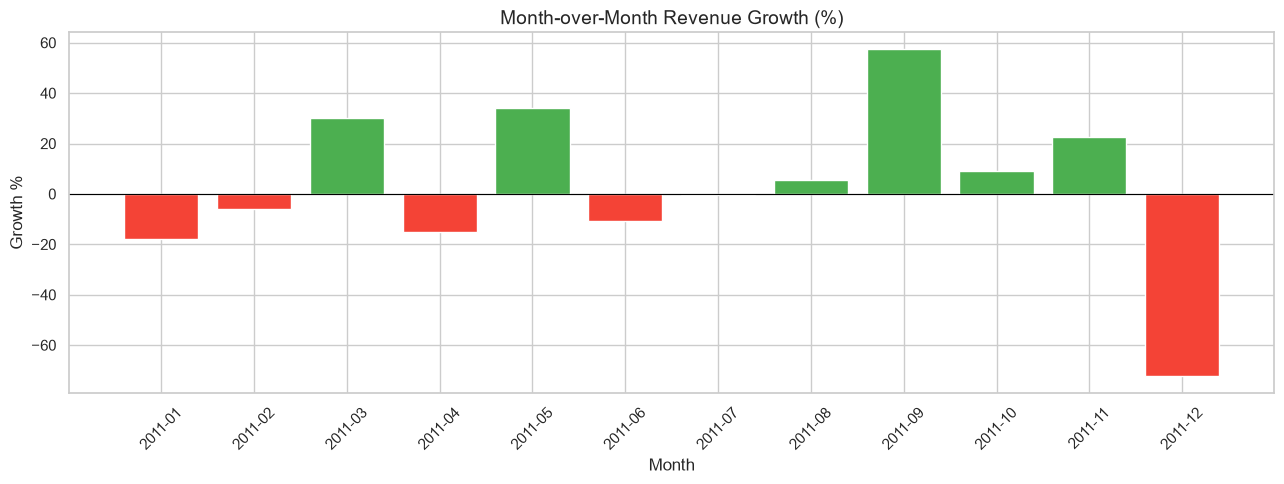

In [28]:
q9 = query("""
    WITH MonthlyRev AS (
        SELECT 
            Year, Month,
            ROUND(SUM(TotalPrice), 2) AS Revenue
        FROM orders
        GROUP BY Year, Month
    )
    SELECT 
        Year, Month, Revenue,
        LAG(Revenue) OVER (ORDER BY Year, Month) AS PrevRevenue,
        ROUND(
            (Revenue - LAG(Revenue) OVER (ORDER BY Year, Month))
            / LAG(Revenue) OVER (ORDER BY Year, Month) * 100, 2
        ) AS GrowthPct
    FROM MonthlyRev
    ORDER BY Year, Month
""")

print('💡 Q9: Month-over-Month Revenue Growth %')
display(q9)

# Plot growth %
q9_clean = q9.dropna(subset=['GrowthPct'])
q9_clean['Period'] = q9_clean['Year'].astype(str) + '-' + q9_clean['Month'].astype(str).str.zfill(2)

colors = ['#4CAF50' if x >= 0 else '#F44336' for x in q9_clean['GrowthPct']]
plt.figure(figsize=(13, 5))
plt.bar(q9_clean['Period'], q9_clean['GrowthPct'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Month-over-Month Revenue Growth (%)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Growth %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/sql_q9_mom_growth.png', dpi=150)
plt.show()

### ❓ Business Question 10 — High Value vs Low Value Product Revenue Share

💡 Q10: Revenue Share by Product Price Category


,PriceCategory,ProductCount,TotalRevenue,AvgRevPerProduct
0,Budget (<£3),4602,2883304.95,626.53
1,Mid-Range (£3–£9.99),1886,1416171.23,750.89


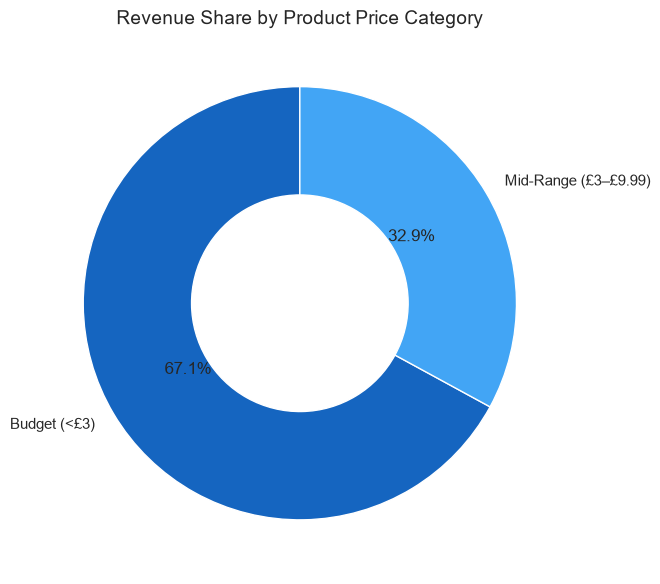

In [29]:
q10 = query("""
    WITH ProductRevenue AS (
        SELECT 
            Description,
            UnitPrice,
            ROUND(SUM(TotalPrice), 2) AS TotalRevenue
        FROM orders
        GROUP BY Description, UnitPrice
    )
    SELECT 
        CASE 
            WHEN UnitPrice >= 10 THEN 'Premium (≥£10)'
            WHEN UnitPrice >= 3  THEN 'Mid-Range (£3–£9.99)'
            ELSE 'Budget (<£3)'
        END AS PriceCategory,
        COUNT(*)                        AS ProductCount,
        ROUND(SUM(TotalRevenue), 2)     AS TotalRevenue,
        ROUND(AVG(TotalRevenue), 2)     AS AvgRevPerProduct
    FROM ProductRevenue
    GROUP BY PriceCategory
    ORDER BY TotalRevenue DESC
""")

print('💡 Q10: Revenue Share by Product Price Category')
display(q10)

# Donut chart
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    q10['TotalRevenue'],
    labels=q10['PriceCategory'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#1565C0', '#42A5F5', '#90CAF9'],
    wedgeprops=dict(width=0.5)
)
ax.set_title('Revenue Share by Product Price Category', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/sql_q10_price_category.png', dpi=150)
plt.show()

---
## 🗃️ Reusable Database Utility Script
Save commonly used queries as Python functions

In [30]:
# ── Database Utility Functions ──

def get_top_products(n=5):
    """Return top N products by revenue"""
    return query(f"""
        SELECT Description, ROUND(SUM(TotalPrice),2) AS Revenue
        FROM orders GROUP BY Description
        ORDER BY Revenue DESC LIMIT {n}
    """)

def get_country_summary():
    """Return revenue summary by country"""
    return query("""
        SELECT Country,
               ROUND(SUM(TotalPrice),2)     AS Revenue,
               COUNT(DISTINCT CustomerID)   AS Customers,
               COUNT(DISTINCT InvoiceNo)    AS Orders
        FROM orders GROUP BY Country ORDER BY Revenue DESC
    """)

def get_monthly_trend():
    """Return month-by-month revenue"""
    return query("""
        SELECT Year, Month, ROUND(SUM(TotalPrice),2) AS Revenue
        FROM orders GROUP BY Year, Month ORDER BY Year, Month
    """)

def get_customer_summary(top_n=10):
    """Return top N customers by spend"""
    return query(f"""
        SELECT CustomerID, Country,
               ROUND(SUM(TotalPrice),2)  AS TotalSpend,
               COUNT(DISTINCT InvoiceNo) AS TotalOrders
        FROM orders GROUP BY CustomerID
        ORDER BY TotalSpend DESC LIMIT {top_n}
    """)

# ── Test the utility functions ──
print('=== TOP 5 PRODUCTS ===')
display(get_top_products(5))

print('\n=== TOP 5 CUSTOMERS ===')
display(get_customer_summary(5))

=== TOP 5 PRODUCTS ===


,Description,Revenue
0,PARTY BUNTING,34952.85
1,WHITE HANGING HEART T-LIGHT HOLDER,31763.76
2,JUMBO BAG RED RETROSPOT,24923.50
3,SPOTTY BUNTING,23513.05
4,ASSORTED COLOUR BIRD ORNAMENT,22940.06



=== TOP 5 CUSTOMERS ===


,CustomerID,Country,TotalSpend,TotalOrders
0,14911,EIRE,84980.89,193
1,13089,United Kingdom,36347.88,80
2,14096,United Kingdom,36019.84,17
3,17841,United Kingdom,32224.59,123
4,14298,United Kingdom,24387.53,40


---
## 💾 Save SQL Queries to a .sql File

In [31]:
q6 = query("""
    SELECT 
        CASE CAST(strftime('%w', InvoiceDate) AS INTEGER)
            WHEN 0 THEN 'Sunday'
            WHEN 1 THEN 'Monday'
            WHEN 2 THEN 'Tuesday'
            WHEN 3 THEN 'Wednesday'
            WHEN 4 THEN 'Thursday'
            WHEN 5 THEN 'Friday'
            WHEN 6 THEN 'Saturday'
        END AS DayOfWeek,
        COUNT(DISTINCT InvoiceNo)      AS TotalOrders,
        ROUND(SUM(TotalPrice), 2)      AS TotalRevenue,
        ROUND(AVG(TotalPrice), 2)      AS AvgOrderValue
    FROM orders
    GROUP BY DayOfWeek
    ORDER BY TotalRevenue DESC
""")

print('💡 Q6: Best Day of the Week for Sales')
display(q6)

💡 Q6: Best Day of the Week for Sales


,DayOfWeek,TotalOrders,TotalRevenue,AvgOrderValue
0,Thursday,3672,927269.41,14.03
1,Wednesday,3096,771937.56,13.58
2,Tuesday,2864,744324.30,13.44
3,Monday,2587,702198.86,12.86
4,Friday,2530,647459.81,14.12
5,Sunday,2077,506286.24,9.30


In [32]:
# Close the connection
conn.close()
print('✅ Database connection closed.')

✅ Database connection closed.


---
## ✅ Task 2 Complete!

**What we accomplished:**
- ✅ Loaded cleaned dataset into SQLite database
- ✅ Practised SQL fundamentals: SELECT, WHERE, ORDER BY, GROUP BY, HAVING, LIKE
- ✅ Used Advanced SQL: Subqueries, CTEs (WITH), Window Functions (ROW_NUMBER, RANK, LAG)
- ✅ Created a reusable VIEW for customer summary
- ✅ Connected Python to SQLite via SQLAlchemy
- ✅ Answered 10 business questions using SQL + visualizations
- ✅ Built reusable Python database utility functions
- ✅ Saved all queries to `scripts/task2_queries.sql`

**Next Steps:**
1. Push this notebook + `.sql` file to GitHub
2. Record a screen recording
3. Post on LinkedIn and submit on the ApexPlanet portal
4. Move to **Task 3 — Data Visualization & Dashboarding** 🚀

---
*ApexPlanet Data Analytics Internship — Task 2 of 5*